In [10]:
import yfinance as yf
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import io

# Exercise 1: Tesla Stock Data via yfinance
tesla = yf.Ticker("TSLA")
tesla_data = tesla.history(period="max")
tesla_data.reset_index(inplace=True)
print(tesla_data.head())

# Exercise 2: Tesla Revenue Data via Web Scraping
url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/revenue.htm"
html_data = requests.get(url).text
soup = BeautifulSoup(html_data, "html.parser")

# Parse table rows
tesla_revenue = pd.read_html(str(soup))[0]
tesla_revenue.columns = ['Date', 'Revenue']

# Clean string formatting
tesla_revenue["Revenue"] = tesla_revenue['Revenue'].str.replace(r'[\$,]', '', regex=True)
tesla_revenue.dropna(inplace=True)
tesla_revenue = tesla_revenue[tesla_revenue['Revenue'] != ""]

print(tesla_revenue.tail())

                       Date      Open      High       Low     Close  \
0 2010-06-29 00:00:00-04:00  1.266667  1.666667  1.169333  1.592667   
1 2010-06-30 00:00:00-04:00  1.719333  2.028000  1.553333  1.588667   
2 2010-07-01 00:00:00-04:00  1.666667  1.728000  1.351333  1.464000   
3 2010-07-02 00:00:00-04:00  1.533333  1.540000  1.247333  1.280000   
4 2010-07-06 00:00:00-04:00  1.333333  1.333333  1.055333  1.074000   

      Volume  Dividends  Stock Splits  
0  281494500        0.0           0.0  
1  257806500        0.0           0.0  
2  123282000        0.0           0.0  
3   77097000        0.0           0.0  
4  103003500        0.0           0.0  
    Date Revenue
8   2013    2013
9   2012     413
10  2011     204
11  2010     117
12  2009     112


C:\Users\Reese\AppData\Local\Temp\ipykernel_14248\4194775881.py:20: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tesla_revenue = pd.read_html(str(soup))[0]


In [11]:
# Exercise 3: GameStop Stock Data via yfinance
gme = yf.Ticker("GME")
gme_data = gme.history(period="max")
gme_data.reset_index(inplace=True)
print(gme_data.head()) # <-- Required Output for 1.4

# ==========================================
# Exercise 4: GameStop Revenue Data via Web Scraping
# ==========================================

# Using the direct, reliable lab data source endpoint for GameStop revenue
url_gme = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-PY0220EN-SkillsNetwork/labs/project/stock.html"

# 1. Fetch the data
html_data_gme = requests.get(url_gme).text

# 2. Extract the table. On this specific page layout, the revenue table 
# is located at index 1.
gme_revenue = pd.read_html(io.StringIO(html_data_gme))[1]

# 3. Rename columns to match the lab requirements
gme_revenue.columns = ['Date', 'Revenue']

# 4. Clean string formatting characters ($ and commas)
gme_revenue["Revenue"] = gme_revenue['Revenue'].str.replace(r'[\$,]', '', regex=True)

# 5. Drop empty spaces or rows missing values
gme_revenue.dropna(inplace=True)
gme_revenue = gme_revenue[gme_revenue['Revenue'].str.strip() != ""]

print("GameStop Revenue Data Tail:")
print(gme_revenue.tail())

                       Date      Open      High       Low     Close    Volume  \
0 2002-02-13 00:00:00-05:00  1.620129  1.693350  1.603296  1.691667  76216000   
1 2002-02-14 00:00:00-05:00  1.712707  1.716073  1.670626  1.683250  11021600   
2 2002-02-15 00:00:00-05:00  1.683250  1.687458  1.658001  1.674834   8389600   
3 2002-02-19 00:00:00-05:00  1.666418  1.666418  1.578047  1.607504   7410400   
4 2002-02-20 00:00:00-05:00  1.615920  1.662210  1.603296  1.662210   6892800   

   Dividends  Stock Splits  
0        0.0           0.0  
1        0.0           0.0  
2        0.0           0.0  
3        0.0           0.0  
4        0.0           0.0  
GameStop Revenue Data Tail:
          Date Revenue
57  2006-01-31    1667
58  2005-10-31     534
59  2005-07-31     416
60  2005-04-30     475
61  2005-01-31     709


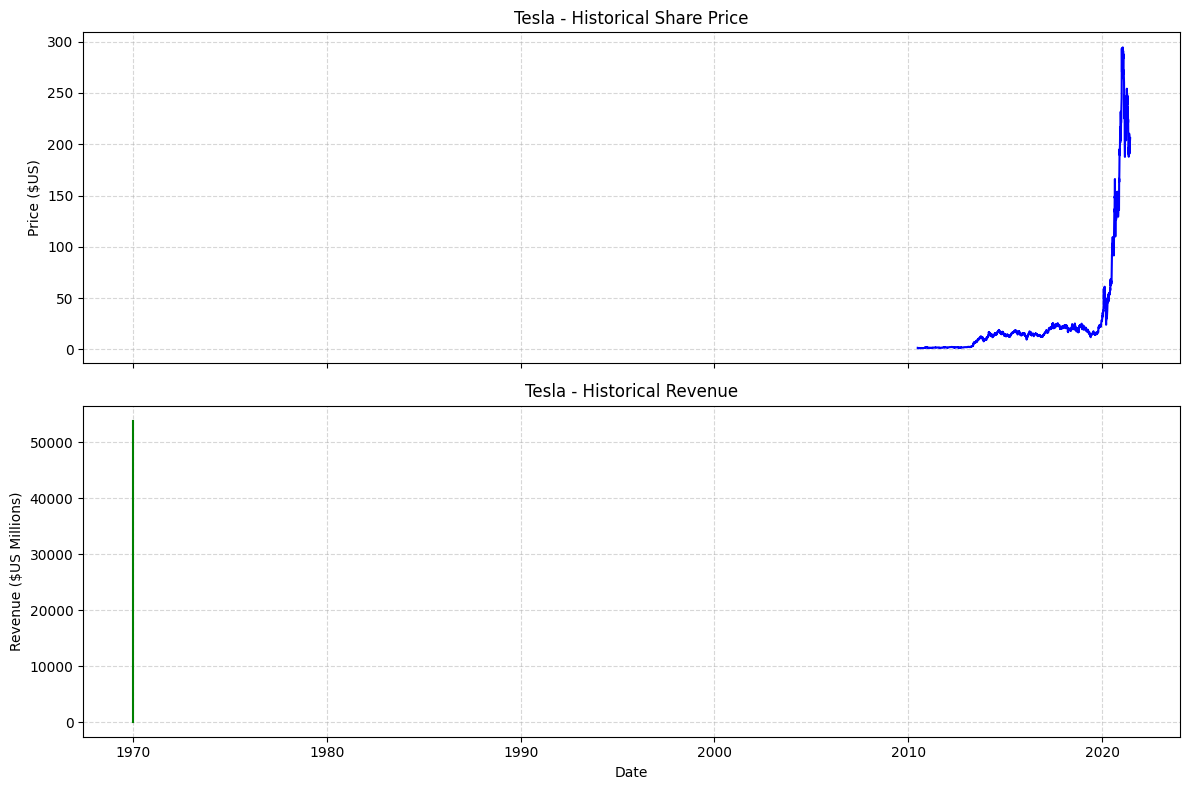

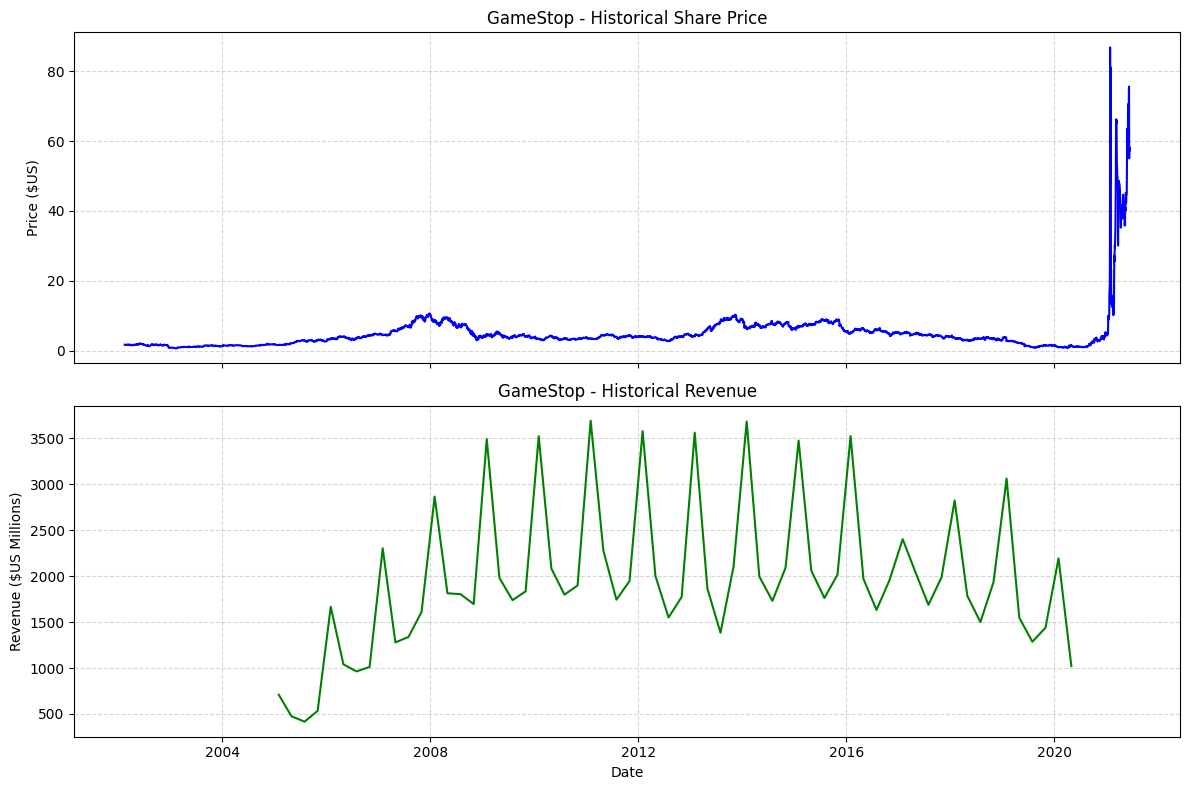

In [12]:
def make_graph(stock_data, revenue_data, stock):
    """
    Custom dashboard plotting function provided by IBM Coursera.
    Plots historical share price alongside historical revenue.
    """
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
    
    # Format dates safely
    stock_data_copy = stock_data.copy()
    revenue_data_copy = revenue_data.copy()
    stock_data_copy['Date'] = pd.to_datetime(stock_data_copy['Date'])
    revenue_data_copy['Date'] = pd.to_datetime(revenue_data_copy['Date'])
    
    # Filter dates up to 2021 to match lab requirements
    stock_data_copy = stock_data_copy[stock_data_copy['Date'] <= '2021-06-14']
    revenue_data_copy = revenue_data_copy[revenue_data_copy['Date'] <= '2021-04-30']
    
    # Plot 1: Share Price Trend
    ax1.plot(stock_data_copy['Date'], stock_data_copy['Close'], color="blue", label="Share Price")
    ax1.set_ylabel("Price ($US)")
    ax1.set_title(f"{stock} - Historical Share Price")
    ax1.grid(True, linestyle="--", alpha=0.5)
    
    # Plot 2: Revenue Trend
    # Convert revenue to numeric values to avoid plotting errors
    revenue_data_copy['Revenue'] = pd.to_numeric(revenue_data_copy['Revenue'])
    ax2.plot(revenue_data_copy['Date'], revenue_data_copy['Revenue'], color="green", label="Revenue")
    ax2.set_ylabel("Revenue ($US Millions)")
    ax2.set_xlabel("Date")
    ax2.set_title(f"{stock} - Historical Revenue")
    ax2.grid(True, linestyle="--", alpha=0.5)
    
    plt.tight_layout()
    plt.show()

# Exercise 5: Plot Tesla Dashboard
make_graph(tesla_data, tesla_revenue, 'Tesla')

# Exercise 6: Plot GameStop Dashboard
make_graph(gme_data, gme_revenue, 'GameStop')